# Exploring Thermal Vulnerability Across Life Stages, Endpoints, Geography, IUCN Statuses: A Reproducible Data Analysis Framework

## Project Motivation
Inspired by the research themes of the PEACE lab and the Thermal Ecology Alliance, this project hopes to explore how thermal tolerance varies and how uncertainty in thermal tolerance estimates may influence the assessments of climate vulnerability. Rather than focusing solely on average thermal limits, this data analysis adopts a quantitative perspective that considers any variability, uncertainty or data limitations. 

## Objectives
The objectives of this proiect are to: 
1. Characterize the distribution of thermal tolerance measurements across developmental stages in two orders of amphibians - Anura (frogs) and Caudata (salamanders).
2. Quantify differences in thermal tolerance among life stages and endpoints.
3. Identify potential taxonomic and geographic biases.
4. Evaluate uncertainty associated with thermal tolerance estimates.
5. Develop an initial framework for incorporating uncertainty into climate vulnerability assessments.

## Data Sources
This analysis uses the **AmphiTherm** database, a comprehensive collection of amphibian thermal tolerance and thermal preference measurements compiled from studies conducted worldwide. Two main orders of amphibians are included in this data - anura and caudata. The database provides standardized information on thermal physiology, life stage, acclimation conditions, species identity, and experimental design. Dr. Patrice Pottier's [PEACE Lab](https://patricepottierlab.com/) championed the aggregation of data from hundreds of various studies. The repository containing the code and data can be accessed here: [AmphiTherm](https://github.com/p-pottier/AmphiTherm).

## Reproducibility and Open Source Science
A central goal of this project is to follow the PEACE Lab's principles of open and reproducible research. All data processing, analyses, visualizations, and statistical summaries are conducted within this Jupyter Notebook using transparent workflows. Every figure and result can be reproduced directly from the original dataset.\
This notebook is intended both as an exploratory research exercise and as a demonstration of my interest in applying quantitative methods, uncertainty quantification, and reproducible analytical workflows to questions that address the effects of climate change on our biodiversity.

### Import all the necessary Python packages:

In [826]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import plotly.express as px


## Study 1: Characterizing Thermal Tolerance Across Life Stages
This first study focuses on understanding the structure and limitations of the available thermal tolerance data. Speficially, it addresses Objectives 1-3 introduced above.

In additiona to these objectives, Study 1 lays the foundation for later analyses by exploring the uncertainty associated wtih thermal tolerance estimates. Understanding where data is abundant, where knowledge gaps exist, and how thermal tolerance varies is a necessary first step.

The results of this study will directly motivate Study 2, which will investigate how uncertainty in thermal tolerance estimates propagates into climate vulnerability assessments.

In [827]:
df = pd.read_csv("Cleaned_and_curated_data_Amphitherm.csv", encoding="latin1")

print(df.shape)
print(df.columns.tolist())

(4401, 84)
,['unique_ID', 'name', 'ref', 'title', 'pub_year', 'thesis_chapter', 'chapter_title', 'peer_reviewed', 'doi', 'language', 'population_ID', 'cohort_ID', 'notes_ID', 'order', 'family', 'species', 'strain', 'IUCN_status', 'origin', 'n_generations_lab', 'latitude', 'longitude', 'elevation', 'date_sampling', 'month_sampling', 'year_sampling', 'start_range_sampling_dates', 'end_range_sampling_dates', 'notes_sampling', 'ambient_temp', 'substrate_temp', 'water_temp', 'field_body_temp', 'notes_env_temp', 'acclimated', 'incubation_temp', 'sd_incubation_temp', 'life_stage_acclimated', 'gosner_acclimated', 'acclimation_temp', 'sd_acclimation_temp', 'acclimation_time', 'notes_acclimation', 'life_stage_tested', 'gosner_tested', 'SVL', 'body_mass', 'age_tested', 'sex', 'metric', 'endpoint', 'medium_test_temp', 'start_temp', 'ramping', 'set_time', 'n_test_temp', 'n_replicates_per_temp', 'n_animals_per_replicate', 'duration_measurement', 'rate_measurement', 'gradient_type', 'gradient_low_tem

In [828]:
num_order = df["order"].nunique()
print(num_order)

2


In [829]:
num_family = df["family"].nunique()
print(num_family)

37


In [830]:
num_species = df["species"].nunique()
print(num_species)

614


In [831]:
metric_values = np.array(df["metric"].unique())

In [832]:
print(metric_values)

['CTmax' 'Tpref' 'CTmin' 'LT50_cold' 'LT50_hot']


In [833]:
metric_count = []

for i in metric_values:
    metric_count.append((df["metric"] == i).sum())

In [834]:
print(metric_count)

[np.int64(2756), np.int64(679), np.int64(908), np.int64(9), np.int64(49)]


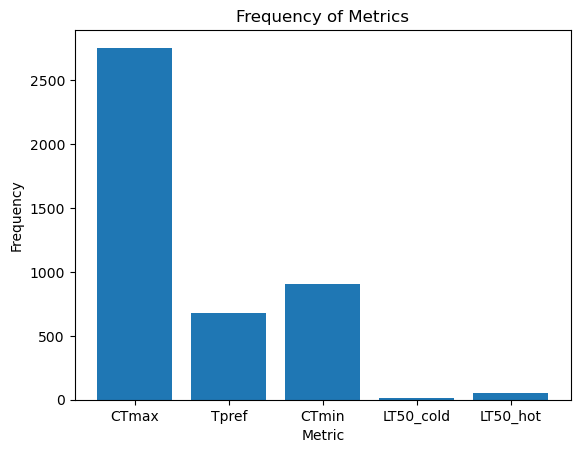

In [835]:
plt.bar(metric_values, metric_count)

plt.xlabel("Metric")
plt.ylabel("Frequency")
plt.title("Frequency of Metrics")

plt.show()

In [836]:
ctmax_df = df[df["metric"]=="CTmax"].copy()

print(ctmax_df.shape)

print(ctmax_df["life_stage_tested"].value_counts(dropna=False))

(2756, 84)
,life_stage_tested
,adults        1391
,larvae        1162
,juveniles      125
,metamorphs      78
,Name: count, dtype: int64


In [837]:
ctmax_df["life_stage_tested"].unique()

array(['larvae', 'metamorphs', 'adults', 'juveniles'], dtype=object)

### Study 1.1 - Evaluating Thermal Tolerances Across Life Stage and Endpoint

The AmphiTherm database contains 4,401 observations and 84 variables. Restricting the analysis to upper thermal limits (CTmax) yields 2,756 observations. Initial exploration reveals substantial differences in representation across developmental stages.

Adults (1,391 observations) and larvae (1,162 observations) account for the vast majority of available thermal tolerance measurements, while metamorphs (78 observations) and juveniles (125 observations) are comparatively underrepresented. This uneven distribution suggests that our current understanding of thermal vulnerability may be biased toward specific developmental stages and motivates further investigation into potential knowledge gaps.

Before comparing thermal tolerance across life stages, it is therefore important to understand both the biological patterns and the uncertainty associated with the available data.

In [838]:
life_stage_summary = (ctmax_df.groupby("life_stage_tested").agg(n_obs=("mean_trait","count"), n_species=("species","nunique")).sort_values("n_obs", ascending=False))

life_stage_summary

,n_obs,n_species
life_stage_tested,,
adults,1391,345
larvae,1162,277
juveniles,125,35
metamorphs,78,19


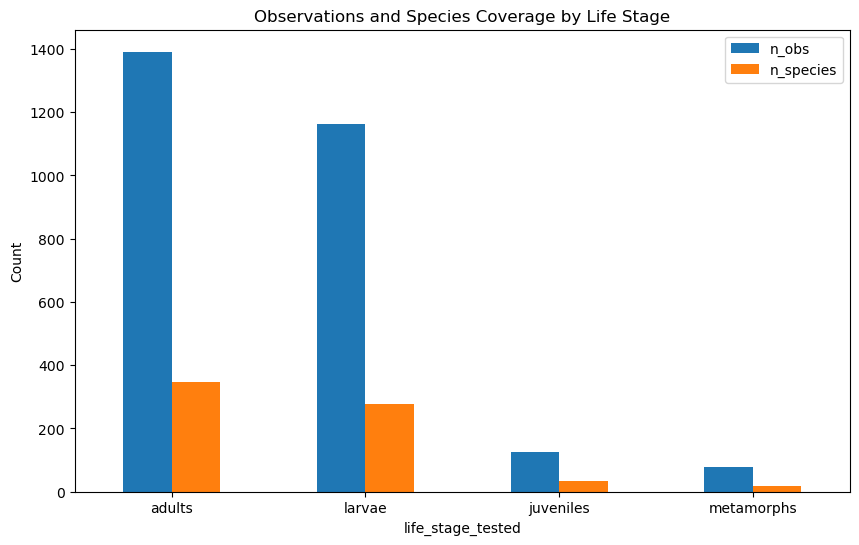

In [839]:
ax = life_stage_summary.plot(kind="bar", figsize=(10,6))

plt.title("Observations and Species Coverage by Life Stage")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [840]:
life_stage_summary["pct_obs_total"] = (life_stage_summary["n_obs"] / life_stage_summary["n_obs"].sum())*100

life_stage_summary

,n_obs,n_species,pct_obs_total
life_stage_tested,,,
adults,1391,345,50.471698
larvae,1162,277,42.162554
juveniles,125,35,4.535559
metamorphs,78,19,2.830189


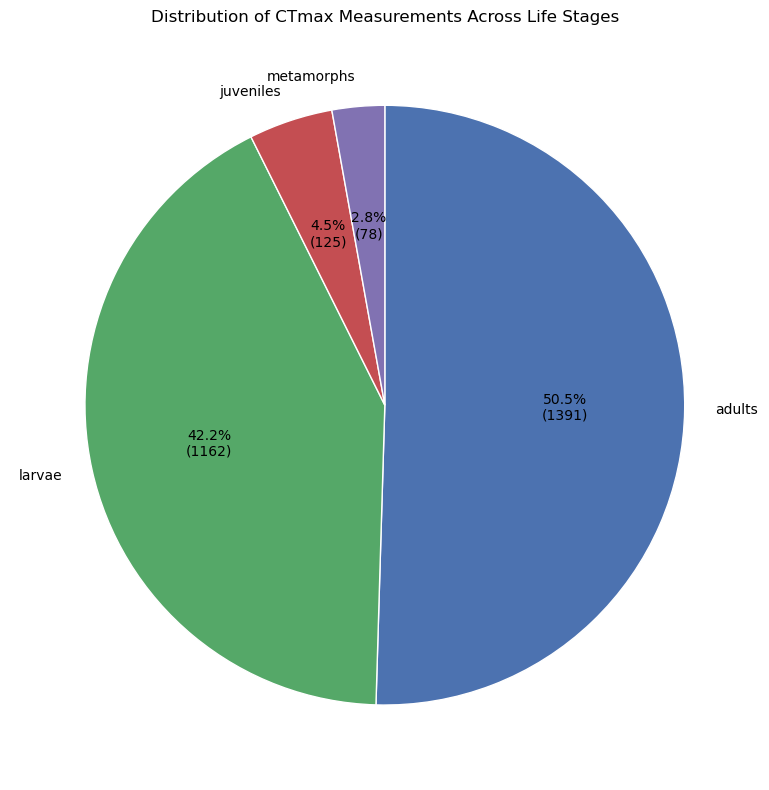

In [841]:

colors = [
    "#4C72B0",
    "#55A868",
    "#C44E52",
    "#8172B2"
]

plt.figure(figsize=(8,8))

plt.pie(
    life_stage_summary["n_obs"],
    labels=life_stage_summary.index,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p/100*life_stage_summary['n_obs'].sum()))})",
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops={"edgecolor":"white"}
)

plt.title("Distribution of CTmax Measurements Across Life Stages")

plt.tight_layout()
plt.show()


### Initial Findings

The thermal tolerance literature is heavily skewed toward adults and larvae, while juveniles and metamorphs remain relatively understudied.

The dataset also exhibits considerable methodological heterogeneity. Thermal tolerance was quantified using multiple experimental endpoints, including loss of righting response (LRR), loss of equilibrium (LOE), onset of spasms (OS), prodding response, and death. Consequently, variability in thermal tolerance estimates may arise not only from biological differences among organisms but also from differences in experimental methodology.



### Statistical Comparison by Life Stages

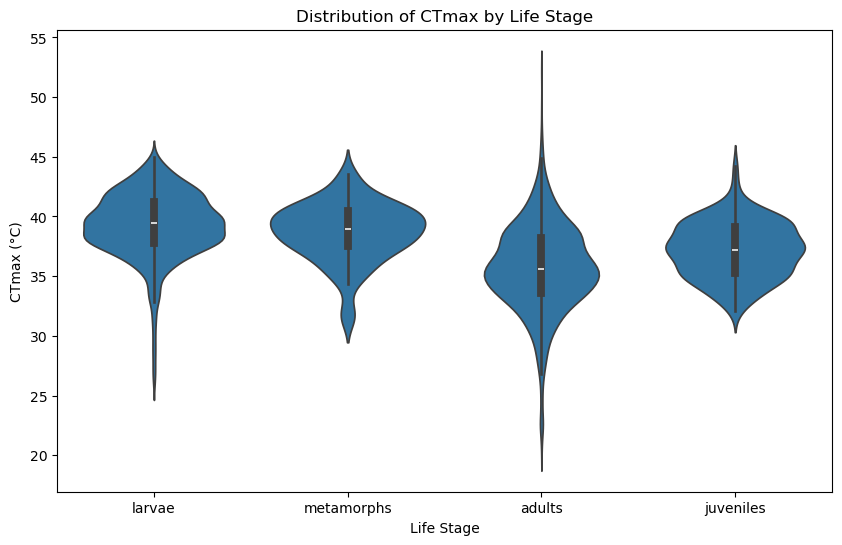

In [842]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=ctmax_df,
    x="life_stage_tested",
    y="mean_trait"
)

plt.xlabel("Life Stage")
plt.ylabel("CTmax (°C)")

plt.title("Distribution of CTmax by Life Stage")

plt.show()

In [843]:
ctmax_df.groupby("life_stage_tested")["mean_trait"].describe()

,count,mean,std,min,25%,50%,75%,max
life_stage_tested,,,,,,,,
adults,1391.0,35.700296,3.645609,20.415000,33.603170,35.600000,38.175537,52.170000
juveniles,125.0,37.198719,2.314554,32.068337,35.230769,37.194245,39.155556,44.200000
larvae,1162.0,39.263497,2.763258,25.979221,37.800000,39.457898,41.200000,45.000000
metamorphs,78.0,38.687912,2.438951,31.500000,37.511364,38.960795,40.416376,43.549575


### Kruskal-Wallis Test by Life Stages:
The KW Test is a non-paramateric alternative to ANOVA. It asks, "Do the thermal tolerance distributions differ between at least one pair of life stages? 

In our case, the null hypothesis (H0) is: All life stages have the same CTmax distribution.

In [844]:
from scipy.stats import kruskal

groups = [group["mean_trait"].dropna()
    for _, group in ctmax_df.groupby(
        "life_stage_tested"
    )
]

kruskal(*groups)

KruskalResult(statistic=np.float64(717.6900357214399), pvalue=np.float64(3.062677534756465e-155))

$$ H = 717.69, p = 3.06*10^{-155} $$

A Kruskal-Wallis test revealed highly significant differences in CTmax among developmental stages (H=717.69 and p<0.001). The p-value is effectively zero, so we can confidently reject the null hypothesis that all life stages produce the same CTmax distribution. Thermal tolerance distributions are not uniform across the life cycle and suggests variation in heat tolerance.

In [845]:
import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(
    ctmax_df,
    val_col="mean_trait",
    group_col="life_stage_tested",
    p_adjust="bonferroni"
)

posthoc

,adults,juveniles,larvae,metamorphs
adults,1.000000e+00,6.246569e-04,3.115086e-154,2.181786e-13
juveniles,6.246569e-04,1.000000e+00,1.199872e-12,1.939806e-03
larvae,3.115086e-154,1.199872e-12,1.000000e+00,8.362806e-01
metamorphs,2.181786e-13,1.939806e-03,8.362806e-01,1.000000e+00


Subsequent pairwise Dunn tests indicated that adults, juveniles, and larvae all differed significantly from one another after multiple-comparison correction. In contrast, larval and metamorphic stages did not differ significantly (p = 0.836), suggesting comparable distributions of upper thermal limits between these developmental stages. These findings support the hypothesis that thermal tolerance varies throughout the life cycle but that certain transitions may be associated with relatively stable thermal limits.

### Statistical Analysis by Endpoint

Based on an initial review of the dataset and its accompanying metadata, the endpoint appears to represent the physiological response used to determine when an amphibian has reached its upper thermal tolerance limit (CTmax). In other words, endpoints describe the observable biological response (e.g., loss of equilibrium, loss of righting response, or onset of spasms) that signals upper thermal capacity and is used to record the corresponding CTmax value.

| Endpoint     | Meaning                   |
| ------------ | ------------------------- |
| **LRR**      | Loss of Righting Response |
| **LOE**      | Loss of Equilibrium       |
| **OS**       | Onset of Spasms           |
| **Prodding** | No response to prodding   |
| **Death**    | Death                     |
| **Other**    | Miscellaneous endpoints   |


In [846]:
ctmax_df["endpoint"].value_counts(dropna=False)

endpoint
LRR         974
prodding    804
OS          762
other       135
LOE          49
death        32
Name: count, dtype: int64

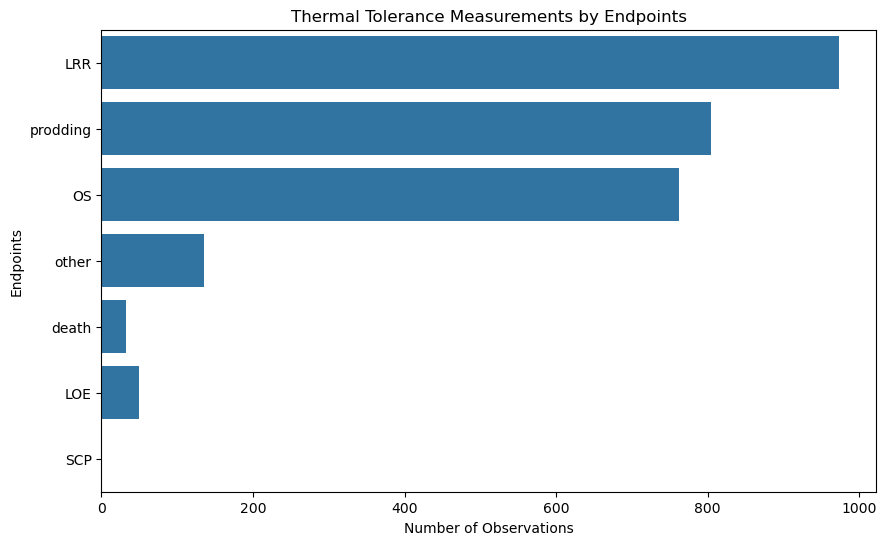

In [847]:
plt.figure(figsize=(10,6))

sns.countplot(data=ctmax_df, y="endpoint", order=df["endpoint"].value_counts().index)

plt.title("Thermal Tolerance Measurements by Endpoints")
plt.xlabel("Number of Observations")
plt.ylabel("Endpoints")

plt.show()

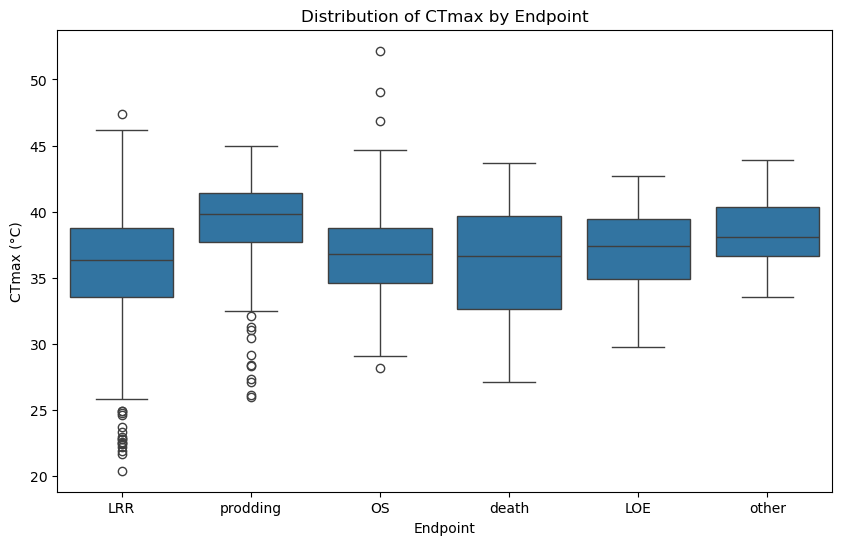

In [848]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=ctmax_df,
    x="endpoint",
    y="mean_trait"
)

plt.xlabel("Endpoint")
plt.ylabel("CTmax (°C)")

plt.title("Distribution of CTmax by Endpoint")

plt.show()

In [849]:
ctmax_df.groupby("endpoint")["mean_trait"].describe()

,count,mean,std,min,25%,50%,75%,max
endpoint,,,,,,,,
LOE,49.0,36.787673,3.171469,29.800000,34.936420,37.397810,39.418600,42.700000
LRR,974.0,35.992846,4.091756,20.415000,33.539815,36.344406,38.770532,47.423077
OS,762.0,36.816588,2.923200,28.200000,34.600000,36.767417,38.800000,52.170000
death,32.0,36.108356,4.560848,27.120000,32.670000,36.630000,39.674517,43.700000
other,135.0,38.329939,2.274779,33.548416,36.682130,38.100000,40.362068,43.900000
prodding,804.0,39.436462,2.806358,25.979221,37.730000,39.799281,41.403784,45.000000


In [850]:
from scipy.stats import kruskal

groups = [group["mean_trait"].dropna()
    for _, group in ctmax_df.groupby("endpoint")]

kruskal(*groups)

KruskalResult(statistic=np.float64(469.84008778835005), pvalue=np.float64(2.576530162975433e-99))

$$ H = 469.84,   p = 2.57*10^{-99} $$

Kruskal-Wallis for the endpoints revealed similar results that was seen earlier among developmental life stages. CTmax distributions among the different endpoints is vastly different (H = 469.84, p<0.0001). The p-value here is also effectively zero, rejecting the null hypothesis. 

In [851]:
import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(
    ctmax_df,
    val_col="mean_trait",
    group_col="endpoint",
    p_adjust="bonferroni"
)

posthoc

,LOE,LRR,OS,death,other,prodding
LOE,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,2.017027e-01,9.748256e-07
LRR,1.000000e+00,1.000000e+00,3.061023e-01,1.000000,6.058831e-09,1.380435e-88
OS,1.000000e+00,3.061023e-01,1.000000e+00,1.000000,1.123033e-05,1.523612e-61
death,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.425607e-01,1.093518e-05
other,2.017027e-01,6.058831e-09,1.123033e-05,0.142561,1.000000e+00,5.733513e-04
prodding,9.748256e-07,1.380435e-88,1.523612e-61,0.000011,5.733513e-04,1.000000e+00


The pairwise Dunn tests tell us which endpoints differ. 

| Comparison        | p-value  |
| ----------------- | -------- |
| Prodding vs LOE   | 9.75e-07 |
| Prodding vs LRR   | 1.38e-88 |
| Prodding vs OS    | 1.52e-61 |
| Prodding vs Death | 1.09e-05 |
| Prodding vs Other | 5.73e-04 |


As seen in the able above, every comparison involving **Prodding** is significant. This suggests that CTmax values obtained using the Prodding endpoint are systematically different from those obtained using most other physiological endpoints. This aligns with the box-plot seen above where the mean CTmax for Prodding was noticeably higher than all other endpoints. 

| Comparison   | p-value |
| ------------ | ------- |
| LOE vs LRR   | 1.00    |
| LOE vs OS    | 1.00    |
| LOE vs Death | 1.00    |
| LRR vs Death | 1.00    |
| OS vs Death  | 1.00    |

All other comparisons are non-significant, meaning most conventional thermal endpoints generate relatively similar thermal tolerance estimates. In pragmatic terms if one study uses LOE and another uses LRR, their CTmax estimates might be comparable (as long as the specimen physiology, family, speciies are relatively similar).

In [852]:
pd.crosstab(ctmax_df["life_stage_tested"], ctmax_df["endpoint"])

endpoint,LOE,LRR,OS,death,other,prodding
life_stage_tested,,,,,,
adults,6,648,560,2,115,60
juveniles,0,54,16,1,8,46
larvae,43,259,180,29,12,639
metamorphs,0,13,6,0,0,59


### Methodological Bias Across Life Stages

Cross-tabulation (pd.crosstab) of life stage and experimental endpoint revealed substantial methodological imbalance across developmental stages. Adults were predominantly assessed using loss of righting response (LRR) and onset of spasms (OS), whereas larval observations were heavily concentrated in studies using the prodding endpoint.
Because previous analyses demonstrated significant differences in CTmax estimates among endpoint categories, these results suggest that some of the observed life-stage differences may be influenced by methodological variation. Consequently, endpoint selection may act as a confounding variable in comparative assessments of thermal tolerance across developmental stages.

This finding highlights the importance of accounting for experimental methodology when synthesizing thermal tolerance datasets and interpreting climate-vulnerability estimates.


In [853]:
import statsmodels.formula.api as smf

model = smf.ols("mean_trait ~ C(life_stage_tested) + C(endpoint)", data=ctmax_df).fit()

print(model.summary())

                            OLS Regression Results                            
,==============================================================================
,Dep. Variable:             mean_trait   R-squared:                       0.280
,Model:                            OLS   Adj. R-squared:                  0.278
,Method:                 Least Squares   F-statistic:                     133.6
,Date:                Sat, 12 Sep 2026   Prob (F-statistic):          8.02e-190
,Time:                        14:36:12   Log-Likelihood:                -7023.2
,No. Observations:                2756   AIC:                         1.406e+04
,Df Residuals:                    2747   BIC:                         1.412e+04
,Df Model:                           8                                         
,Covariance Type:            nonrobust                                         
,======================================================================================================
,                

### Joint Effects of Life Stage and Methodology

To determine whether observed differences in thermal tolerance arose solely from biological variation or were influenced by methodological differences among studies, an ordinary least squares (OLS) regression model was fitted with life stage and experimental endpoint as explanatory variables.

The model explained that approximately 28% of the variation in CTmax (R² = 0.28) arose from life stage and endpoint. The remaining 72% likely comes from: biological differences in species, geography, experimental design and possibly measurement uncertainty.

**Interpreting the model results summary**:

1. The model automatically uses adults and LOE as the reference categories for life stage and endpoint, respectively. 
2. Relative to adults, larvae, metamorphs, and juveniles exhibited significantly higher thermal tolerance estimates. Importantly, these effects remained significant even after accounting for endpoint differences. For example, juveniles exhibit 1.33C higher heat tolerance than adults and larvae exhibit 3.32C higher heat tolerance than adults.
3. Endpoint effects were also substantial. In particular, studies using the "Prodding" endpoint reported CTmax estimates approximately 2.7C higher than studies using the loss-of-equilibrium (LOE) endpoint. Compared to LOE, all other endpoints were significant, except death (-0.82C and P>|t| = 0.247), meaning that after accounting for life stage, there is no difference between CTmax estimates obtained using the "death" endpoint and those obtained using LOE. This finding suggests that differences in experimental design may contribute significantly to variability in reported thermal tolerance values. 

Together, these results indicate that both biological and methodological factors influence thermal tolerance estimates and should be considered when developing climate-vulnerability assessments based on comparative thermal datasets.

In [854]:
model2 = smf.ols("mean_trait ~ C(life_stage_tested, Treatment(reference = 'larvae')) + C(endpoint, Treatment(reference = 'LRR'))", data=ctmax_df).fit()

print(model2.summary())

                            OLS Regression Results                            
,==============================================================================
,Dep. Variable:             mean_trait   R-squared:                       0.280
,Model:                            OLS   Adj. R-squared:                  0.278
,Method:                 Least Squares   F-statistic:                     133.6
,Date:                Sat, 12 Sep 2026   Prob (F-statistic):          8.02e-190
,Time:                        14:36:12   Log-Likelihood:                -7023.2
,No. Observations:                2756   AIC:                         1.406e+04
,Df Residuals:                    2747   BIC:                         1.412e+04
,Df Model:                           8                                         
,Covariance Type:            nonrobust                                         
,========================================================================================================================

### Changing the reference categories from adult and LOE to larvae and LRR.

In the initial model, the reference categories were selected automatically by the software and corresponded to **adults** and **LOE (Loss of Equilibrium)**. While this produced a valid model fit, these reference groups were not ideal for interpretation because LOE represented only a small fraction of observations (49 out of the 2756).

The new model was therefore refitted using: 
- **Larvae** as the reference life stage
- **LRR** as the reference endpoint

These categories were chosen because they are amont the most frequently represented groups within the dataset. Using the most common categories as references improves interpretability and allows all estimated coefficients to be compared against biologically and statistically well-supported baselines.

#### Key Findings
The refitted model revealed significant effects of both developmental stage and experimental methodology on thermal tolerance estimates.

#### Biological Effects (Life Stage)
Relative to larvae:

- Adults exhibited CTmax values approximately **3.3C lower**.
- Juveniles exhibited CTmax values approximately **2.0C lower**.
- Metamorphs exhibited CTmax values approximately **0.9C lower**.
 
All three effects remained statistically significant after controlling for endpoint differences, indicating that developmental stage itself contributes substantially to variation in thermal tolerance.


#### Methodological Effects (Endpoint)
Relative to the LRR endpoint:

- The *prodding* endpoint produced CTmax values approximately **1.5C higher**.
- The *OS (Onset of Spasms)* endpoint produced CTmax values approximately **1.0C higher**.
- The *other* category produced CTmax values approximately **3.0C higher**.
- The *death* endpoint produced CTmax values approximately **2.0C lower**.


#### The Case of the "Death" Endpoint
An especially interesting result concerns the *death* endpoint. In the original model, where LOE served as the reference category, the coefficient associated with death was **not statistically significant** (-0.82C and P>|t| = 0.247). This initially suggested that thermal tolerance estimates based on mortality were broadly comparable to those obtained using LOE.
However, once the reference category was changed to LRR, the *death* endpoint became statistically significant (-1.948C and P>|t| = 0.001). This does not indicate that the underlying biological relationship changed. Rather, it highlights the fact that statistical significance in categorical models is always interpreted relative to the chosen reference category. Simply put: 

- **Death and LOE are statistically similar endpoints** with respect to CTmax estimates (original model)
- **Death and LRR differ significantly**, indicating that mortality-based endpoints may produce systematically different thermal tolerance estimates when compared with LRR-based measurements (new model)

#### Implications
Taken together, these analyses suggest that both **biology** (developmental stage) and **methodology** (endpoint definition) influence measured thermal tolerance. Consequently, comparisons of thermal vulnerability across species and life stages should account for methodological heterogeneity. Failure to do so may lead to over- or underestimation of thermal sensitivity and obscure the biological mechanisms underlying climate vulnerability across the life cycle.

In other words, 
$$ CT_{max} = Biology + Methodology + Residual Variation $$

The new model should be interpreted as,
$$ CT_{max} = \beta_{0} + \beta_{1}(Adults) + \beta_{2}(Juveniles) + \beta_{3}(Metamorphs) + \beta_{4}(LOE) + \beta_{5}(OS) + \beta_{6}(death) + \beta_{7}(other) + \beta_{8}(prodding) $$

and, $$\beta_{0} = Larvae \space measured \space using \space LRR.$$

## Study 1.2: Geographical Bias

Research question - Are thermal measurements concentrated in specific regions of the world? What climatic conditions are over or underrepresented?

In [855]:
ctmax_df["latitude"].isna().sum()

np.int64(408)

In [856]:
ctmax_df = ctmax_df.dropna(subset=["latitude"]).copy()

In [857]:
print(ctmax_df.shape)

(2348, 84)


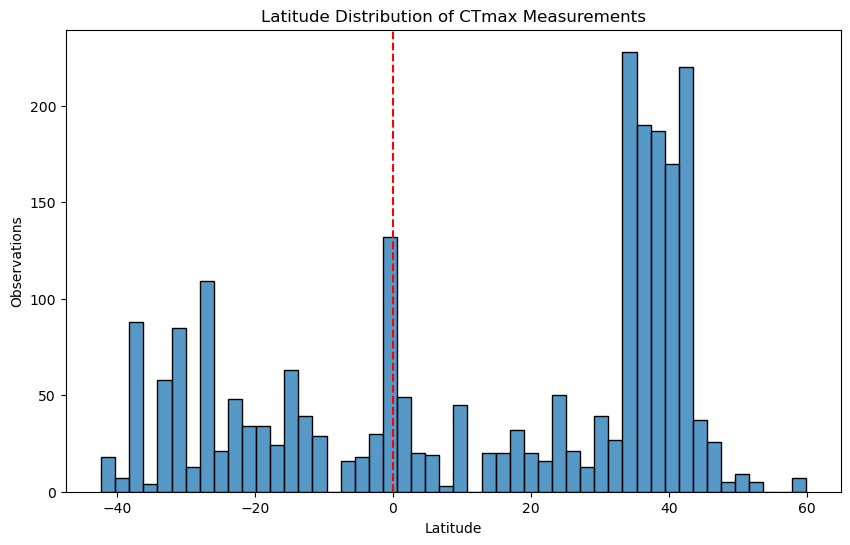

In [858]:

plt.figure(figsize=(10,6))

sns.histplot(ctmax_df["latitude"], bins=50 )

plt.axvline(0, color="red", linestyle="--")

plt.xlabel("Latitude")
plt.ylabel("Observations")

plt.title("Latitude Distribution of CTmax Measurements")

plt.show()

In [859]:

conditions = [
    np.abs(ctmax_df["latitude"]) <= 23.5,
    (np.abs(ctmax_df["latitude"]) > 23.5) & (np.abs(ctmax_df["latitude"]) <= 35),
    (np.abs(ctmax_df["latitude"]) > 35) & (np.abs(ctmax_df["latitude"]) <= 60),
    np.abs(ctmax_df["latitude"]) > 60
]

choices = [
    "Tropical",
    "Subtropical",
    "Temperate",
    "Polar"
]

ctmax_df["climate_zone"] = np.select(conditions, choices, default="Unknown")
ctmax_df["climate_zone"].value_counts()

climate_zone
Temperate      1034
Tropical        692
Subtropical     622
Name: count, dtype: int64

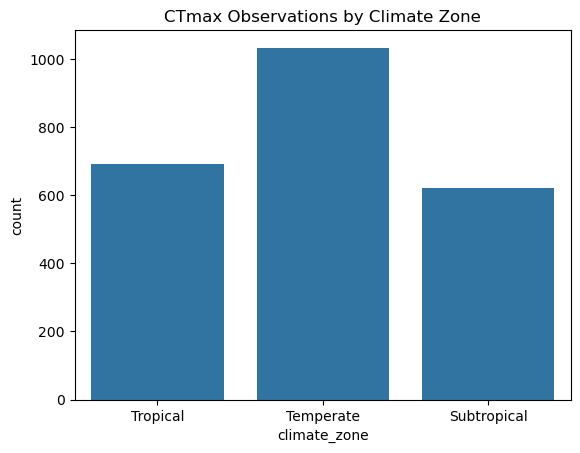

In [860]:
sns.countplot(data=ctmax_df, x="climate_zone")

plt.title("CTmax Observations by Climate Zone")

plt.show()

In [861]:
ctmax_df["hemisphere"] = np.where(ctmax_df["latitude"] >= 0, "Northern", "Southern")

ctmax_df["hemisphere"].value_counts()

hemisphere
Northern    1487
Southern     861
Name: count, dtype: int64

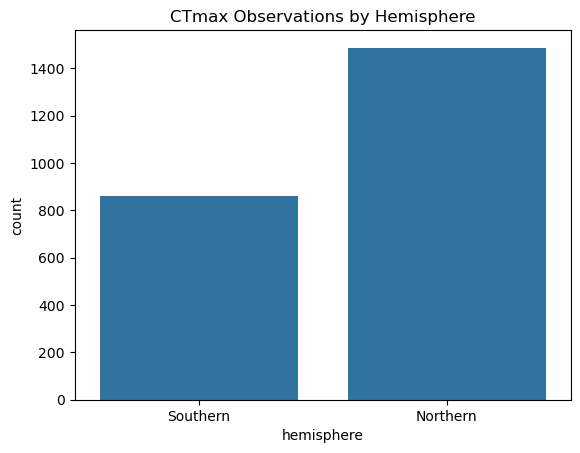

In [862]:
sns.countplot(data=ctmax_df, x="hemisphere")

plt.title("CTmax Observations by Hemisphere")

plt.show()

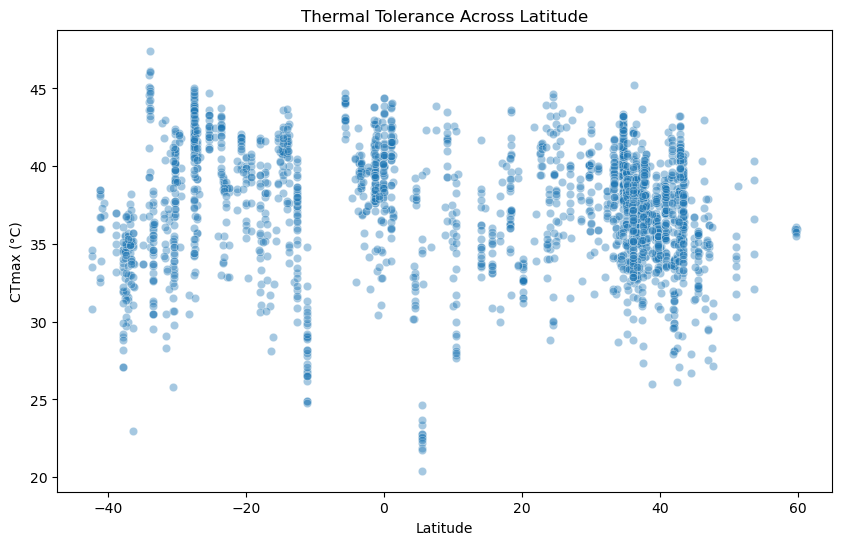

<Axes: xlabel='latitude', ylabel='mean_trait'>

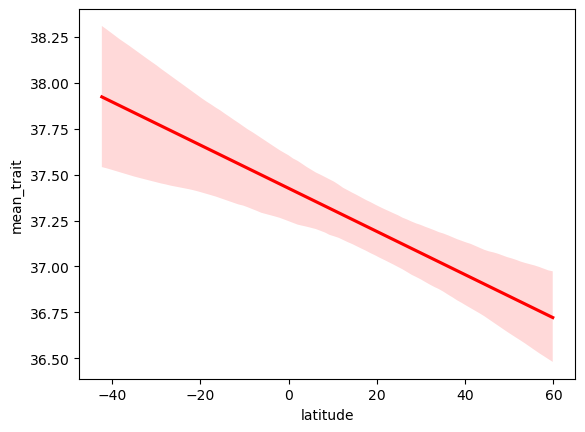

In [863]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=ctmax_df,
    x="latitude",
    y="mean_trait",
    alpha=0.4
)

plt.ylabel("CTmax (°C)")
plt.xlabel("Latitude")

plt.title("Thermal Tolerance Across Latitude")

plt.show()

sns.regplot(
    data=ctmax_df,
    x="latitude",
    y="mean_trait",
    scatter=False,
    color="red"
)

### Geographic Bias Findings

Thermal tolerance exhibited a weak but consistent relationship with latitude. Linear regression suggested that CTmax tends to decrease with increasing latitude, indicating that organisms inhabiting lower-latitude regions generally possess higher upper thermal tolerance limits than organisms from higher latitudes - as was expected.

However, substantial variability was observed at nearly every latitude, with many species exhibiting markedly different thermal tolerance values despite originating from similar geographic regions. This suggests that latitude alone explains only a small fraction of thermal tolerance variation.

Taken together, these results indicate that geographic location contributes to thermal tolerance patterns but does not fully determine them. Instead, thermal tolerance likely emerges from a combination of geographic, biological, and methodological factors, including species identity, developmental stage, acclimation history, etc. Based on the analysis and evidence conducted in this study, the dependence of the thermal tolerance on various factors can be summarized as, 

$$ CT_{max} = f(life \space stage, \space endpoint, \space geography, \space species \space identity, local \space environment) $$


In [864]:
iucn_obs = (ctmax_df["IUCN_status"].value_counts().sort_index())

iucn_obs

IUCN_status
CR      16
DD      36
EN      66
LC    2002
NT     148
VU      80
Name: count, dtype: int64

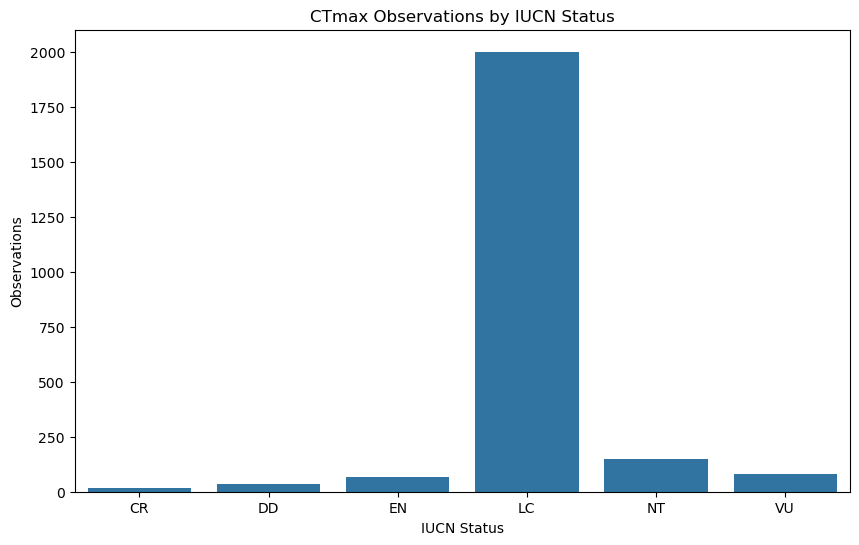

In [865]:
plt.figure(figsize=(10,6))

sns.countplot(data=ctmax_df, x="IUCN_status", order=sorted(ctmax_df["IUCN_status"].dropna().unique()))

plt.title("CTmax Observations by IUCN Status")

plt.xlabel("IUCN Status")
plt.ylabel("Observations")

plt.show()

In [866]:
species_iucn = (ctmax_df.groupby("IUCN_status")["species"].nunique().sort_values(ascending=False))

species_iucn

IUCN_status
LC    385
NT     38
VU     34
EN     26
DD     21
CR      8
Name: species, dtype: int64

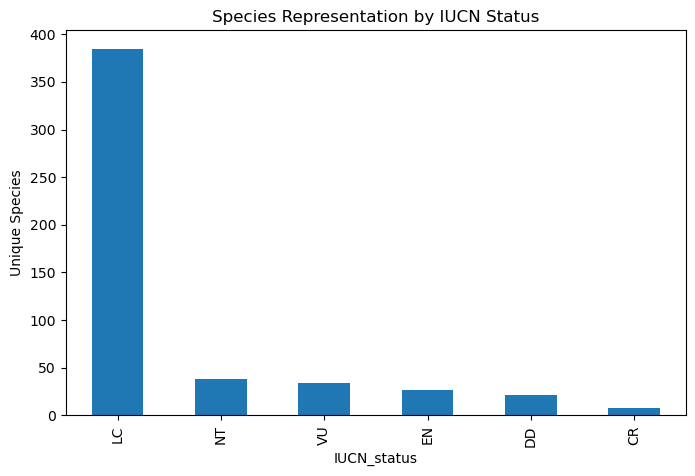

In [867]:
species_iucn.plot(kind="bar", figsize=(8,5))

plt.title("Species Representation by IUCN Status")
plt.ylabel("Unique Species")

plt.show()

In [868]:
pd.crosstab(ctmax_df["IUCN_status"], ctmax_df["climate_zone"])

climate_zone,Subtropical,Temperate,Tropical
IUCN_status,,,
CR,1,9,6
DD,16,0,20
EN,5,7,54
LC,539,938,525
NT,40,50,58
VU,21,30,29


### Representation across IUCN Categories

A final objective of study 1 was to evaluate the distribution of thermal tolerance research across IUCN statuses. Understanding this distribution is important because it drives future climate-vulnerability assessments for endangered species, but more importantly, for proactive measures to avoid species becoming endangered.

The analysis revealed a substantial imbalance in the distribution of thermal tolerance across coservation categories - DD (data deficient), LC (least concern), NT (near threatened), VU (vulnerable), EN (endangered), CR (critically endangered) and EX (extinct). Species classified as **LC** accounted for the overwhelming majority of both CTmax observations and unique species represented in the dataset. In contrast, all other categories contributed substantially fewer observations. More importantly, this pattern persisted between observation-level counts and species-level counts.

### Climate Zone and Conservation Status Crosstab
Cross-tabulation of IUCN and climate zones revealed that EN species were disproportionately concentrated in the tropical environments, whereas LC species dominated the dataset across all climate zones. There were no DD species in the temperate zone.



















## Study 2: Quantifying Uncertainty in Thermal Tolerance Estimates.

**Primary question - How much uncertainty exists in reported CTmax estimates across developmental stages and endpoints?**

The analysis in the first study showed significant differences in thermal tolerance across life stages and endpoints. But, point estimates alone do not provide information about how reliable or precise these measurements are. The objective in Study 2 is to quantify the uncertainty associated with reported CTmax estimates. Using the measurement error (error_trait and error_type) and sample-size information (n_trait) available in the AmphiTherm database, this study will try to investigate how uncertainty varies across developmental stages and experimental endpoints.

In [869]:
ctmax_df[["error_trait", "n_trait"]].describe()

,error_trait,n_trait
count,1809.000000,2322.000000
mean,0.436530,14.433247
std,0.491734,14.217310
min,0.010000,2.000000
25%,0.120000,8.000000
50%,0.290000,10.000000
75%,0.554264,15.000000
max,5.347150,210.000000


In [870]:
ctmax_df[["error_trait", "n_trait"]].isna().sum()


error_trait    539
n_trait         26
dtype: int64

In [871]:
ctmax_df["error_type"].value_counts(dropna=False)

error_type
sd     968
se     841
NaN    539
Name: count, dtype: int64

### 2.1 - Characterizing Uncertainty

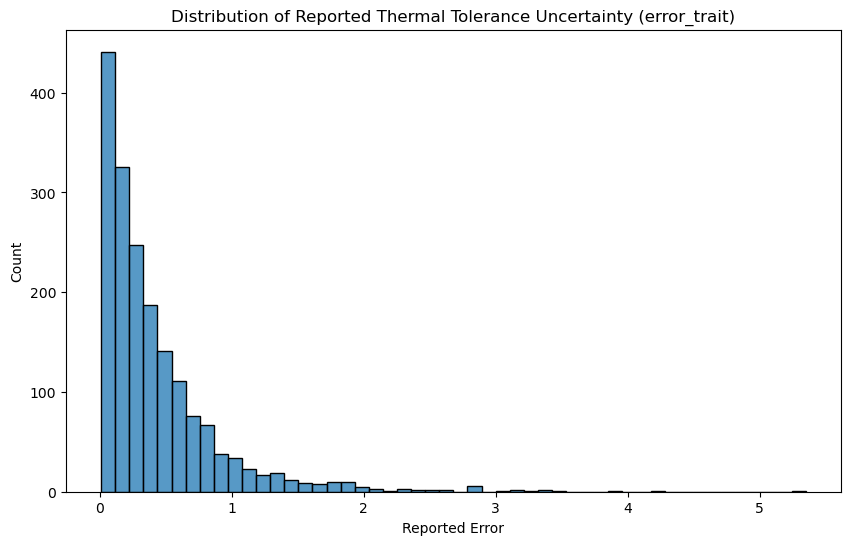

In [872]:
plt.figure(figsize=(10,6))

sns.histplot(ctmax_df["error_trait"].dropna(), bins=50)

plt.xlabel("Reported Error")
plt.ylabel("Count")

plt.title("Distribution of Reported Thermal Tolerance Uncertainty (error_trait)")

plt.show()

In [873]:
ctmax_df["error_trait"].skew()

np.float64(3.1943677231033667)

The distribution of the error_trait (measurement uncertainty) is strongly positively skewed (**skewness = 3.195**) as seen above, indicating that the uncertainty is not evenly distributed among the thermal estimates. Most observations show relatively small uncertain values, whereas a small number of studies have reported substantially larger uncertainty estimates. This pattern suggests that thermal tolerance measurements are generally precise for most observations, but a subset of these records exhibits larger uncertainty estimates.

### 2.2 - Characterizing Uncertainty across Life Stages

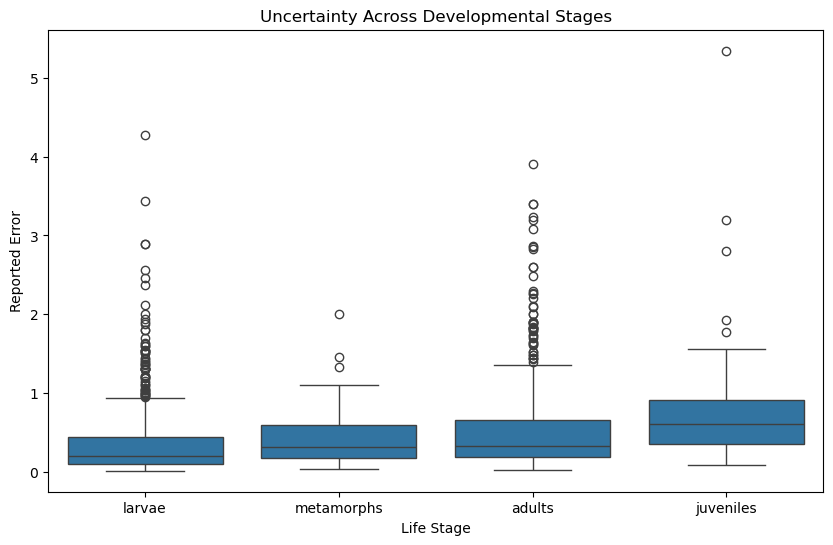

In [874]:
plt.figure(figsize=(10,6))

sns.boxplot(data=ctmax_df, x="life_stage_tested", y="error_trait")

plt.xlabel("Life Stage")
plt.ylabel("Reported Error")

plt.title("Uncertainty Across Developmental Stages")

plt.show()

In [875]:
uncertainty_stage = (ctmax_df.groupby("life_stage_tested")["error_trait"].describe())

uncertainty_stage

,count,mean,std,min,25%,50%,75%,max
life_stage_tested,,,,,,,,
adults,732.0,0.510659,0.530753,0.020837,0.180000,0.319664,0.658282,3.910000
juveniles,92.0,0.754924,0.715465,0.079137,0.350000,0.603030,0.909326,5.347150
larvae,915.0,0.345144,0.410192,0.010000,0.100000,0.200000,0.438047,4.278372
metamorphs,70.0,0.437446,0.378713,0.028329,0.171409,0.305141,0.592657,2.000000


In [876]:
groups = [group["error_trait"].dropna()
    for _, group in ctmax_df.groupby("life_stage_tested")]

kruskal(*groups)

KruskalResult(statistic=np.float64(148.7241790902211), pvalue=np.float64(4.965659503622584e-32))

To evaluate whether measurement uncertainty varies across the life cycle, reported thermal-tolerance errors were compared among developmental stages.

A Kruskal-Wallis test revealed highly significant differences in uncertainty distributions among life stages (**$H = 148.72, p = 5^{-32}$**). Developmental stages therefore differ not only in their reported thermal tolerance estimates, but also in the precision of those estimates: **Juveniles** exhibited the highest average and median uncertainty, while larvae exhibited the lowest. This pattern is particularly notable because juveniles were also among the least represented lfie stages in Study 1, whereas larvae comprised one of the most extensively studied groups. These findings infer that measurement uncertainty is not randomly distributed across the life cycle. Instead, the life stages that receive less research attention may also be characterized by less precise thermal tolerance estimates. This may cause amplification in climate-vulnerability assessments for the life stages where empirical data remains relatively scarce.


### 2.3 - Characterizing Uncertainty across Endpoints

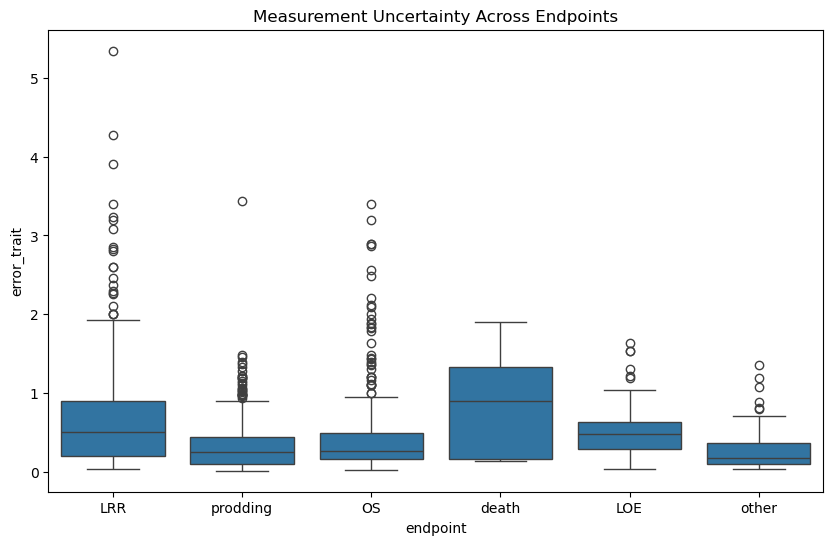

In [877]:
plt.figure(figsize=(10,6))

sns.boxplot(data=ctmax_df, x="endpoint", y="error_trait")

plt.title("Measurement Uncertainty Across Endpoints")

plt.show()

In [878]:
uncertainty_endpoint = (ctmax_df.groupby("endpoint")["error_trait"].describe())

uncertainty_endpoint

,count,mean,std,min,25%,50%,75%,max
endpoint,,,,,,,,
LOE,49.0,0.555103,0.402300,0.034682,0.280,0.480000,0.630000,1.630000
LRR,433.0,0.677451,0.681252,0.037000,0.200,0.500000,0.897300,5.347150
OS,453.0,0.415533,0.481829,0.020837,0.153,0.256228,0.491501,3.400000
death,32.0,0.856301,0.592869,0.130000,0.160,0.900000,1.322500,1.900000
other,128.0,0.254080,0.238262,0.037000,0.100,0.166080,0.359778,1.348921
prodding,714.0,0.309505,0.286276,0.010000,0.100,0.251050,0.433914,3.435113


In [879]:
groups = [group["error_trait"].dropna()
    for _, group in ctmax_df.groupby("endpoint")]

kruskal(*groups)

KruskalResult(statistic=np.float64(192.0598263703408), pvalue=np.float64(1.4173532702135564e-39))

A similar analysis was done for the endpoints to assess whether the measurement precision differed among different methodologies. 

A Kruskal-Wallis test revealed similar significant differences in uncertainty distributions among endpoints (**$H = 192.06, p = 1.41^{-39}$**). These results indicate that methodological choices influence not only the magnitude of thermal tolerance estimates but also their associated uncertainty, which is evident with mortality-based endpoints (death), exhibiting both the highest median error and the greatest variability. In contrast, the prodding and onset-of-spasms (OS) endpoints produced comparatively low uncertainty estimates. Interestingly, the prodding endpoint was previously shown in Study 1 to generate systematically higher CTmax estimates than several alternative methodologies. The results support the conclusion that both biological and methodological factors contribute to uncertainty in thermal tolerance datasets and should therefore be considered when developing comparative analyses and climate-vulnerability assessments.

### 2.4 - Sample Size Effects

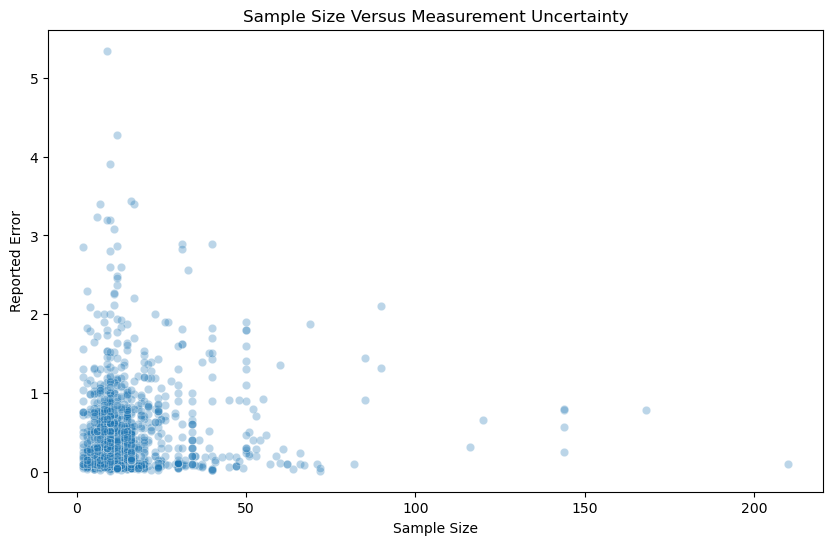

In [880]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=ctmax_df, x="n_trait", y="error_trait", alpha=0.3)

plt.xlabel("Sample Size")
plt.ylabel("Reported Error")

plt.title("Sample Size Versus Measurement Uncertainty")

plt.show()

In [881]:
from scipy.stats import spearmanr

spearmanr(ctmax_df["n_trait"], ctmax_df["error_trait"], nan_policy="omit")

SignificanceResult(statistic=np.float64(-0.026110089841368655), pvalue=np.float64(0.26968703051428783))

A common expectation in experimental research is that larger sample sizes should result in more precise parameter estimates. To evaluate this assumption, reported thermal-tolerance uncertainty was compared against sample size across all CTmax observations. Visual inspection suggested that extremely large uncertainty values were more common among studies with smaller sample sizes. However, a Spearman rank correlation analysis revealed no significant relationship between sample size and reported uncertainty (**$\rho = -0.026, p = 0.270$**). These results suggest that variation in uncertainty is not primarily driven by sample size alone. 

Consequently, uncertainty within thermal tolerance datasets should not be viewed solely as a consequence of limited sampling effort.

### Standardize SD and SE:

In [882]:
ctmax_df["standardized_se"] = np.where(ctmax_df["error_type"] == "sd", ctmax_df["error_trait"] / np.sqrt(ctmax_df["n_trait"]), ctmax_df["error_trait"])

In [883]:
ctmax_df.shape

(2348, 87)

In [884]:
ctmax_df["standardized_se"].describe()

count    1797.000000
mean        0.195641
std         0.205585
min         0.005733
25%         0.095551
50%         0.130312
75%         0.217643
max         2.850000
Name: standardized_se, dtype: float64

In [885]:
ctmax_df["standardized_se"].isna().sum()

np.int64(551)

<Axes: xlabel='standardized_se', ylabel='Count'>

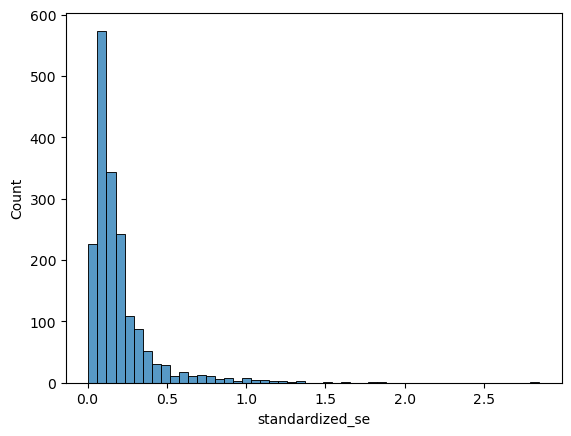

In [886]:
sns.histplot(ctmax_df["standardized_se"].dropna(), bins=50)

Studies within the AmphiTherm database reported uncertainty using either **standard deviation (SD)** or **standard error (SE)**. Because these metrics quantify different aspects of variability, they cannot be compared directly. To ensure consistency across studies, all SD values were converted to SE using:

$$ SE = \frac{SD}{\sqrt{n}} $$

where $n$ is the reported sample size. This standardization allows all uncertainty estimates to be interpreted on a common scale.

### 2.5 - Monte carlo Uncertainty Propogation

Number of observations: 1797


,mean_trait,standardized_se
3310,39.226891,0.360514
1079,42.608899,0.066652
3731,36.111663,0.084367


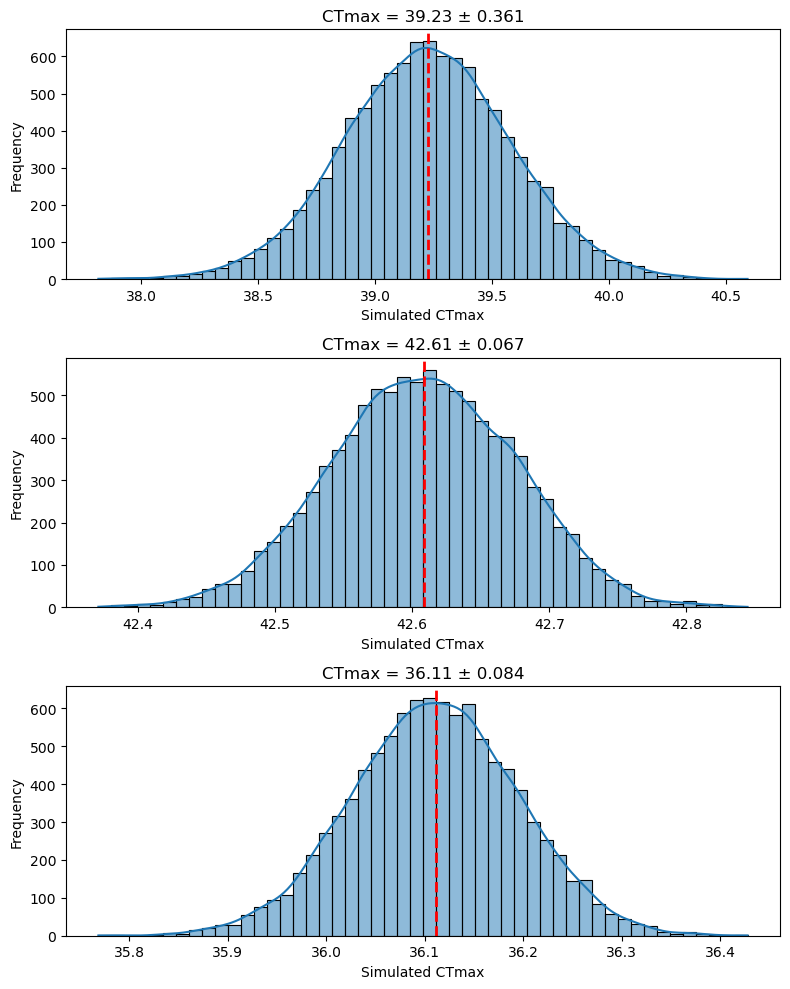

In [887]:
# Create Monte Carlo dataset
mc_df = ctmax_df[["mean_trait", "standardized_se"]].dropna()

print(f"Number of observations: {mc_df.shape[0]}")

# Randomly select three examples
example = mc_df.sample(3, random_state=42)

display(example)

# Generate Monte Carlo distributions
fig, ax = plt.subplots(len(example), 1, figsize=(8, 10))

for i, row in enumerate(example.itertuples()):

    sim = np.random.normal(loc=row.mean_trait, scale=row.standardized_se, size=10000)

    sns.histplot(sim, bins=50, kde=True, ax=ax[i])

    ax[i].axvline(row.mean_trait, color="red", linestyle="--", linewidth=2)

    ax[i].set_title(f"CTmax = {row.mean_trait:.2f} ± {row.standardized_se:.3f}")

    ax[i].set_xlabel("Simulated CTmax")
    ax[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [888]:
results = []

for row in example.itertuples():

    sim = np.random.normal(row.mean_trait, row.standardized_se, 10000)

    results.append({
        "CTmax": round(row.mean_trait, 2),
        "SE": round(row.standardized_se, 3),
        "Lower 95% CI": round(np.percentile(sim, 2.5), 2),
        "Upper 95% CI": round(np.percentile(sim, 97.5), 2)
    })

mc_results = pd.DataFrame(results)

display(mc_results)

,CTmax,SE,Lower 95% CI,Upper 95% CI
0,39.23,0.361,38.54,39.92
1,42.61,0.067,42.48,42.74
2,36.11,0.084,35.95,36.28


In [889]:
stage_df = ctmax_df[["life_stage_tested", "mean_trait", "standardized_se"]].dropna()

In [890]:
stage_df.shape

(1797, 3)

In [891]:
stage_df.head()

,life_stage_tested,mean_trait,standardized_se
0,larvae,41.8,0.070014
1,larvae,41.8,0.096152
2,larvae,42.1,0.110940
3,larvae,41.5,0.129099
4,larvae,41.7,0.258199


In [892]:
stage_df["life_stage_tested"].value_counts()

life_stage_tested
larvae        912
adults        723
juveniles      92
metamorphs     70
Name: count, dtype: int64

In [893]:
n_sim = 10000

results = []

for i in range(n_sim):

    sampled = np.random.normal(loc=stage_df["mean_trait"], scale=stage_df["standardized_se"])

    temp_df = pd.DataFrame({"life_stage": stage_df["life_stage_tested"], "ctmax_sim": sampled})

    stage_means = (temp_df.groupby("life_stage")["ctmax_sim"].mean())

    results.append(stage_means)

sim_df = pd.DataFrame(results)

In [894]:
(sim_df["larvae"] > sim_df["adults"]).mean()

np.float64(1.0)

In [895]:
(sim_df["juveniles"] > sim_df["adults"]).mean()

np.float64(1.0)

In [896]:
(sim_df["metamorphs"] > sim_df["juveniles"]).mean()

np.float64(1.0)

In [897]:
sim_df.shape

(10000, 4)

In [898]:
sim_df = sim_df.reset_index(drop=True)
sim_df.columns.name = None

sim_df.head(10)

,adults,juveniles,larvae,metamorphs
0,36.189760,37.180380,39.213963,38.953000
1,36.217393,37.172352,39.219382,39.021607
2,36.202061,37.157319,39.204355,39.061853
3,36.221181,37.249105,39.217035,38.952177
4,36.220490,37.258554,39.215291,38.998968
5,36.234775,37.180737,39.217431,38.990961
6,36.224725,37.219418,39.213861,39.030298
7,36.228518,37.213296,39.215013,39.013992
8,36.194123,37.167084,39.221398,38.977441
9,36.214119,37.159734,39.224319,38.969779


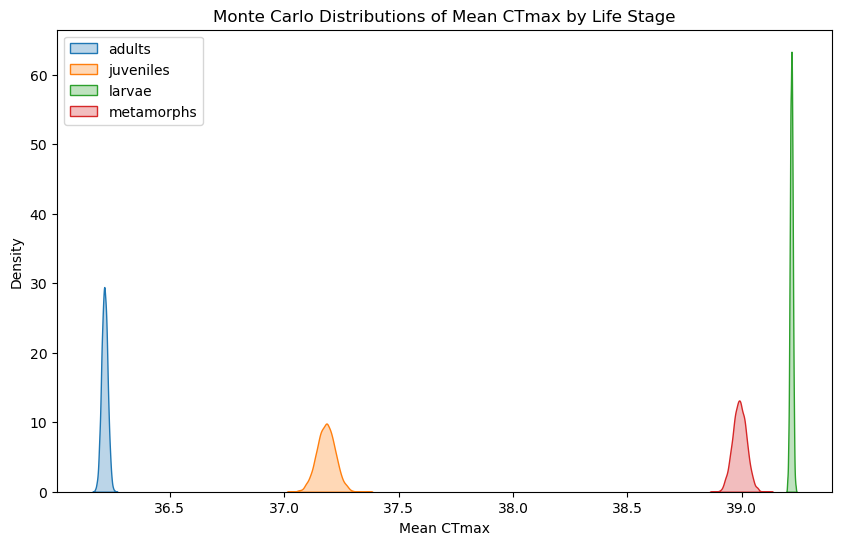

In [899]:
plt.figure(figsize=(10,6))

for stage in sim_df.columns:
    
    sns.kdeplot(sim_df[stage], label=stage, fill=True, alpha=0.3)

plt.xlabel("Mean CTmax")
plt.ylabel("Density")

plt.title("Monte Carlo Distributions of Mean CTmax by Life Stage")

plt.legend()

plt.show()

# Final Conclusions

This project explored thermal tolerance patterns in amphibians using the AmphiTherm database with a particular focus on life stage, endpoints and uncertainty quantification.

## Study 1: Understanding Thermal Tolerance Patterns

The first objective was to characterize the structure of the available thermal tolerance data and identify potential sources of bias and/or variation.

Several important patterns emerged:

1. Thermal tolerance differed significantly across developmental stages. **Larvae** exhibited the highest average CTmax values, followed by metamorphs and juveniles, while adults exhibited the lowest average thermal tolerance. These differences remained statistically significant even after accounting for methodological variation.
2. Thermal tolerance estimates varied significantly among experimental endpoints. In particular, studies using the **prodding** endpoint reported substantially higher CTmax values than studies using other commonly employed physiological endpoints. This demonstrates that methodological choices could influence reported thermal tolerance values and may contribute to discrepancies among studies.
3. Cross-tabulation analyses revealed that different life stages were frequently assessed using different experimental endpoints. Larvae were disproportionately represented in studies using the prodding endpoint, while adults were more commonly assessed using loss of righting response (LRR) and onset of spasms (OS). This indicates that some observed life-stage differences may be influenced by methodological variation.
4. The dataset exhibited representation across tropical, subtropical, and temperate climate zones, with relatively balanced coverage between Northern and Southern Hemisphere observations. While a weak negative relationship between latitude and thermal tolerance was observed (as expected), latitude alone explained only a small fraction of the overall variation in CTmax.
5. Although geographic coverage was relatively broad, tropical zones contained a much higher proportion of endangered species, while the least concern category of species dominated the overall number of observations.

Collectively, these findings suggest that thermal tolerance datasets contain important biological signals but also reflect methodological, geographic, and conservation-related biases that should be considered when conducting thermal ecology studies.

---

## Study 2: Quantifying and Propagating Uncertainty

The second objective was to evaluate how uncertainty is distributed throughout the thermal tolerance literature and determine whether uncertainty influences or changes the conclusions drawn from Study 1.

Key findings included:

1. Measurement uncertainty differed significantly across developmental stages. Juveniles exhibited the highest uncertainty, while larvae exhibited the lowest.
2. Experimental endpoints also differed significantly in their associated uncertainty. Mortality-based endpoints tended to exhibit the largest uncertainty estimates.
3. Sample size alone was not a strong predictor of reported uncertainty, suggesting that biological and methodological factors contribute substantially to variability in thermal tolerance estimates.
4. Reported uncertainty exhibited a strongly right-skewed distribution, indicating that most CTmax estimates are relatively precise while a smaller subset of observations contributes disproportionately large uncertainty.
5. A Monte Carlo simulation was run (10,000 times) to draw from the distribution of the associated CTmax and SE for each life stage. This simulation confirmed findings from study 1: CTmax for Larvae > Metamorphs > Juveniles > Adults.

To account for this uncertainty, all reported error estimates were standardized to standard error units.

# REFERENCES


I would like to acknowledge PEACE Lab and the original authors of the studies that were pivotal in collecting the underlying data. 

The AmphiTherm database can be found here: [AmphiTherm](https://github.com/p-pottier/AmphiTherm)

The references for the original authors are included in the AmphiTherm_database.bib file that is in the "references/" folder of the original repository linked above.